In [ ]:
import torch

TORCH = torch.__version__.split('+')[0]

CUDA = torch.version.cuda.split('+')[0] if torch.cuda.is_available() else 'cpu'

!pip install torch-scatter -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html # for  graph convolution and neighborhood aggregation
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html #for sparse matrix operations
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html  #for clustering operations on graphs
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.8.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.6/645.6 kB 9.8 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.4 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 749.6/749.6 kB 10.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.4/289.4 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.2 MB/s eta 0:00:00


In [ ]:
from torch_geometric.datasets import UPFD
train_data = UPFD(root=".", name="gossipcop", feature="content", split="train")
test_data = UPFD(root=".", name="gossipcop", feature="content", split="test")
print("Train Samples: ", len(train_data))
print("Test Samples: ", len(test_data))

Extracting ./gossipcop/raw/data.zip
Processing...
Done!


Train Samples:  1092
Test Samples:  3826


In [ ]:
"""
Had to import this "manually" due to some errors.
"""

!pip install networkx
import networkx as nx

# From PyG utils
def to_networkx(data, node_attrs=None, edge_attrs=None, to_undirected=False,
                remove_self_loops=False):
    if to_undirected:
        G = nx.Graph()
    else:
        G = nx.DiGraph()
    G.add_nodes_from(range(data.num_nodes))
    node_attrs, edge_attrs = node_attrs or [], edge_attrs or []
    values = {}
    for key, item in data(*(node_attrs + edge_attrs)):
        if torch.is_tensor(item):
            values[key] = item.squeeze().tolist()
        else:
            values[key] = item
        if isinstance(values[key], (list, tuple)) and len(values[key]) == 1:
            values[key] = item[0]
    for i, (u, v) in enumerate(data.edge_index.t().tolist()):
        if to_undirected and v > u:
            continue
        if remove_self_loops and u == v:
            continue
        G.add_edge(u, v)
        for key in edge_attrs:
            G[u][v][key] = values[key][i]
    for key in node_attrs:
        for i, feat_dict in G.nodes(data=True):
            feat_dict.update({key: values[key][i]})
    return G

<Axes: >

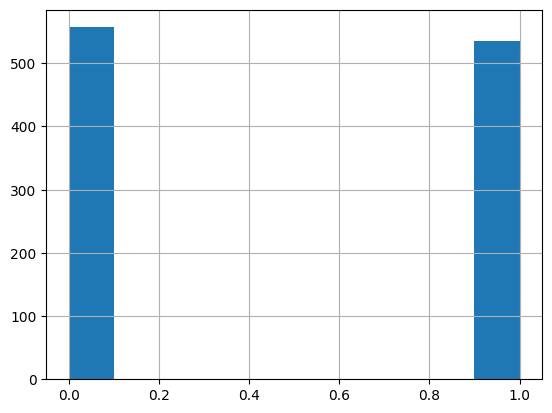

In [ ]:
import pandas as pd
labels = [data.y.item() for i, data in enumerate(train_data)]
df = pd.DataFrame(labels, columns=["Labels"])
df["Labels"].hist()

In [ ]:
from torch_geometric.loader import DataLoader
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

In [ ]:
from torch_geometric.nn import global_max_pool as gmp
from torch_geometric.nn import GATConv
from torch.nn import Linear


class GNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()

        # Graph Convolutions
        self.conv1 = GATConv(in_channels, hidden_channels)
        self.conv2 = GATConv(hidden_channels, hidden_channels)
        self.conv3 = GATConv(hidden_channels, hidden_channels)

        # Readout
        self.lin_news = Linear(in_channels, hidden_channels)
        self.lin0 = Linear(hidden_channels, hidden_channels)
        self.lin1 = Linear(2*hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        # Graph Convolutions
        h = self.conv1(x, edge_index).relu()
        h = self.conv2(h, edge_index).relu()
        h = self.conv3(h, edge_index).relu()

        # Pooling
        h = gmp(h, batch)

        # Readout
        h = self.lin0(h).relu()

        # According to UPFD paper: Include raw word2vec embeddings of news
        # This is done per graph in the batch
        root = (batch[1:] - batch[:-1]).nonzero(as_tuple=False).view(-1)
        root = torch.cat([root.new_zeros(1), root + 1], dim=0)
        # root is e.g. [   0,   14,   94,  171,  230,  302, ... ]
        news = x[root]
        news = self.lin_news(news).relu()

        out = self.lin1(torch.cat([h, news], dim=-1))
        return torch.sigmoid(out)

GNN(train_data.num_features, 128, 1)

GNN(
  (conv1): GATConv(310, 128, heads=1)
  (conv2): GATConv(128, 128, heads=1)
  (conv3): GATConv(128, 128, heads=1)
  (lin_news): Linear(in_features=310, out_features=128, bias=True)
  (lin0): Linear(in_features=128, out_features=128, bias=True)
  (lin1): Linear(in_features=256, out_features=1, bias=True)
)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNN(train_data.num_features, 128, 1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.01)
loss_fnc = torch.nn.BCELoss()

def train(epoch):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = loss_fnc(torch.reshape(out, (-1,)), data.y.float())
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs
    return total_loss / len(train_loader.dataset)

@torch.no_grad()
def test(epoch):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    for data in test_loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        loss = loss_fnc(torch.reshape(out, (-1,)), data.y.float())
        total_loss += float(loss) * data.num_graphs
        all_preds.append(torch.reshape(out, (-1,)))
        all_labels.append(data.y.float())

    # Calculate Metrics
    accuracy, f1 = metrics(all_preds, all_labels)

    return total_loss / len(test_loader.dataset), accuracy, f1


def metrics(preds, gts):
    preds = torch.round(torch.cat(preds))
    gts = torch.cat(gts)
    acc = accuracy_score(preds, gts)
    f1 = f1_score(preds, gts)
    return acc, f1

In [ ]:
for epoch in range(40):
    train_loss = train(epoch)
    test_loss, test_acc, test_f1 = test(epoch)
    print(f'Epoch: {epoch:02d} |  TrainLoss: {train_loss:.2f} | '
          f'TestLoss: {test_loss:.2f} | TestAcc: {test_acc:.2f} | TestF1: {test_f1:.2f}')

/tmp/ipython-input-26801747.py:18: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss) * data.num_graphs


Epoch: 00 |  TrainLoss: 0.70 | TestLoss: 0.70 | TestAcc: 0.50 | TestF1: 0.00
Epoch: 01 |  TrainLoss: 0.69 | TestLoss: 0.69 | TestAcc: 0.50 | TestF1: 0.00
Epoch: 02 |  TrainLoss: 0.69 | TestLoss: 0.68 | TestAcc: 0.53 | TestF1: 0.12
Epoch: 03 |  TrainLoss: 0.68 | TestLoss: 0.69 | TestAcc: 0.50 | TestF1: 0.00
Epoch: 04 |  TrainLoss: 0.68 | TestLoss: 0.68 | TestAcc: 0.50 | TestF1: 0.00
Epoch: 05 |  TrainLoss: 0.67 | TestLoss: 0.65 | TestAcc: 0.61 | TestF1: 0.37
Epoch: 06 |  TrainLoss: 0.68 | TestLoss: 0.64 | TestAcc: 0.71 | TestF1: 0.59
Epoch: 07 |  TrainLoss: 0.67 | TestLoss: 0.65 | TestAcc: 0.50 | TestF1: 0.67
Epoch: 08 |  TrainLoss: 0.66 | TestLoss: 0.64 | TestAcc: 0.50 | TestF1: 0.67
Epoch: 09 |  TrainLoss: 0.64 | TestLoss: 0.62 | TestAcc: 0.88 | TestF1: 0.87
Epoch: 10 |  TrainLoss: 0.62 | TestLoss: 0.64 | TestAcc: 0.52 | TestF1: 0.08
Epoch: 11 |  TrainLoss: 0.61 | TestLoss: 0.57 | TestAcc: 0.92 | TestF1: 0.92
Epoch: 12 |  TrainLoss: 0.61 | TestLoss: 0.62 | TestAcc: 0.54 | TestF1: 0.17

In [ ]:
for data in test_loader:
    data = data.to(device)
    pred = model(data.x, data.edge_index, data.batch)
    df = pd.DataFrame()
    df["pred_logit"] = pred.detach().numpy()[:,0]
    df["pred"] = torch.round(pred).detach().numpy()[:,0]
    df["true"] = data.y.numpy()
    print(df.head(30))
    break

    pred_logit  pred  true
0     0.762262   1.0     1
1     0.585750   1.0     1
2     0.282793   0.0     0
3     0.598321   1.0     1
4     0.079342   0.0     0
5     0.263029   0.0     0
6     0.194179   0.0     0
7     0.863334   1.0     1
8     0.084540   0.0     0
9     0.185239   0.0     0
10    0.796815   1.0     1
11    0.302436   0.0     0
12    0.243890   0.0     0
13    0.411547   0.0     1
14    0.316263   0.0     1
15    0.121227   0.0     0
16    0.764730   1.0     1
17    0.113901   0.0     0
18    0.085439   0.0     0
19    0.721729   1.0     1
20    0.313146   0.0     0
21    0.970443   1.0     1
22    0.114116   0.0     0
23    0.782478   1.0     1
24    0.660422   1.0     1
25    0.610098   1.0     1
26    0.935622   1.0     1
27    0.477569   0.0     1
28    0.384415   0.0     0
29    0.938763   1.0     1
